# Aim 2 - Time to brain metastasis (no-CNS-at-dx cohort)

Final reflection of:
- README Section 8 (KM + Cox PH + AFT spec)
- `src/modeling/aim2_tte_brain_met.py` (KM, log-rank, Cox PH + Schoenfeld zph, AFT distribution selection)
- `src/modeling/_lib.py` (`prep_covariates`, `drop_low_variance`)
- `src/modeling/stratifiedKM_CoxFG_feature_prep_AFT.py` (earlier monolithic pipeline; univariate Cox + multivariable Cox + PH diagnostics)
- `genie_scripts_xgb_aft/run_aft_tuning.py`, `risk_modeling.py`, `run_per_gene_cox_pfs.py`, `run_multivariable_cox_pfs.py`, `diag_cox_test.py`

**Cohort:** `brain_met_at_dx == 0` (n = 1,225 samples). Includes 970 Stage I-III and 255 Stage IV non-CNS dx site.

**Endpoint:** `tt_brain_met_mos` paired with `brain_met_event`.

**Exposure:** `top5_any_mutated`.

**Covariate set (Section 8.2):** `top5_any_mutated + stage_iv_bin + receptor_primary_cat + grade_ord + age_dx_num + race_clean + ethnicity_clean + SEQ_ASSAY_ID`.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import (KaplanMeierFitter, CoxPHFitter,
                       WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter)
from lifelines.statistics import logrank_test, proportional_hazard_test
from sklearn.model_selection import KFold
from statsmodels.stats.multitest import multipletests

PROJ = Path('/Users/robertjames/Documents/Documents - Robert\u2019s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets')
PROC = PROJ / 'data/processed'
FIG  = PROJ / 'manuscript components' / 'figures' / 'aim2'
OUT  = PROJ / 'data/interim' / 'aim2'
MOD  = PROJ / 'src/modeling/genie/aim2'
for p in (FIG, OUT, MOD): p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJ / 'src/modeling'))
import _lib as L

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 110
warnings.simplefilter('ignore')

COHORT = 'genie'
MIN_EVENTS = 25  # matches src/modeling/aim2_tte_brain_met.py
TOP5  = L.load_top_genes(COHORT, n=5)
TOP10 = L.load_top_genes(COHORT, n=10)
print('Top-5:', TOP5)

Top-5: ['TP53', 'PIK3CA', 'GATA3', 'CDH1', 'PTEN']


In [2]:
df = L.load_cohort(COHORT)
base = df[df['brain_met_at_dx'] == 0].copy()
print(f'no-CNS-at-dx cohort  n={len(base)}  events={int(base["brain_met_event"].sum())}')
print(f'  Stage I-III:  {int((base["stage_iv_bin"]==0).sum())}')
print(f'  Stage IV non-CNS dx: {int((base["stage_iv_bin"]==1).sum())}')

no-CNS-at-dx cohort  n=1225  events=384


  Stage I-III:  970
  Stage IV non-CNS dx: 255


## 1. KM + log-rank (Section 8.1)

Stratified by `top5_any_mutated`. Identical curve construction to `aim2_tte_brain_met.py:aim2()` KM block.

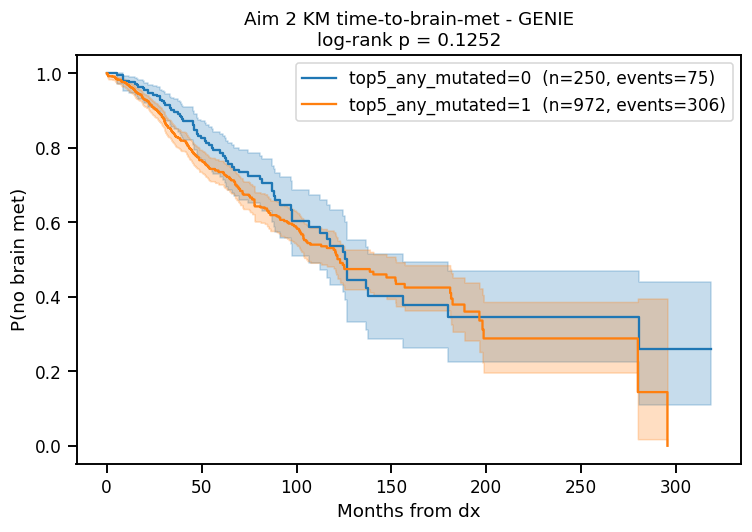

In [3]:
km_df = base[['tt_brain_met_mos', 'brain_met_event', 'top5_any_mutated']].dropna()
km_df = km_df[km_df['tt_brain_met_mos'] > 0]

fig, ax = plt.subplots(figsize=(7, 5))
for grp, sub in km_df.groupby('top5_any_mutated'):
    kmf = KaplanMeierFitter()
    kmf.fit(sub['tt_brain_met_mos'], sub['brain_met_event'],
            label=f'top5_any_mutated={int(grp)}  (n={len(sub)}, events={int(sub.brain_met_event.sum())})')
    kmf.plot_survival_function(ax=ax, ci_show=True)

g0 = km_df[km_df['top5_any_mutated']==0]; g1 = km_df[km_df['top5_any_mutated']==1]
lr = logrank_test(g0['tt_brain_met_mos'], g1['tt_brain_met_mos'],
                  g0['brain_met_event'], g1['brain_met_event'])
ax.set_title(f'Aim 2 KM time-to-brain-met - GENIE\nlog-rank p = {lr.p_value:.4g}')
ax.set_xlabel('Months from dx'); ax.set_ylabel('P(no brain met)')
plt.tight_layout()
plt.savefig(FIG / 'aim2_km.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame([{'test':'log-rank','p_value':lr.p_value,'stat':lr.test_statistic,
               'n_top5_mut': int((km_df['top5_any_mutated']==1).sum()),
               'n_top5_wt':  int((km_df['top5_any_mutated']==0).sum())}]).to_csv(
    OUT / 'aim2_logrank.csv', index=False)

## 2. Cox PH (Section 8.2)

Uses `L.prep_covariates(base, include_stage_iv=True)` and `L.drop_low_variance()` so the modeling frame is byte-identical to the `src/modeling/aim2_tte_brain_met.py` pipeline.

In [4]:
cov = L.prep_covariates(base, include_stage_iv=True)
cph_df = pd.concat([
    base[['tt_brain_met_mos', 'brain_met_event']].reset_index(drop=True),
    cov.reset_index(drop=True),
], axis=1).dropna()
cph_df = cph_df[cph_df['tt_brain_met_mos'] > 0]
cph_cov = L.drop_low_variance(cph_df.drop(columns=['tt_brain_met_mos','brain_met_event']))
fit_df = pd.concat([cph_df[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                    cph_cov.reset_index(drop=True)], axis=1)
events = int(fit_df['brain_met_event'].sum())
print(f'Cox modeling frame: n={len(fit_df)}  events={events}  covariates={cph_cov.shape[1]}')
assert events >= MIN_EVENTS, f'Insufficient events: {events} < {MIN_EVENTS}'

Cox modeling frame: n=1222  events=381  covariates=19


In [5]:
cph = CoxPHFitter(penalizer=0.01)
cph.fit(fit_df, duration_col='tt_brain_met_mos', event_col='brain_met_event', show_progress=False)
cox_summary = cph.summary.reset_index().rename(columns={'covariate':'term'})
cox_summary.to_csv(OUT / 'aim2_cox.csv', index=False)
print(f'C-index = {cph.concordance_index_:.3f}')
cph.print_summary(decimals=3)

C-index = 0.687


<lifelines.CoxPHFitter: fitted with 1222 total observations, 841 right-censored observations>
             duration col = 'tt_brain_met_mos'
                event col = 'brain_met_event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1222
number of events observed = 381
   partial log-likelihood = -2325.559
         time fit was run = 2026-07-14 03:10:03 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
top5_any_mutated                      0.025     1.025     0.130          -0.231           0.281               0.794               1.324
age_dx_num                            0.006     1.006     0.008          -0.009           0.021               0.991               1.021
stage_iv_bin                          0.844     2.326     0.121           0.607           1.082               1.834               2.950
receptor_primary_cat_HR+/HER2-        0.157     1.170     0.139          -0.114           0.429               0.892               1.536
receptor_primary_cat_HR-/HER2+        0.891     2.438     0.206           0.487           1.295               1.627               3.653
receptor_primary_cat_Triple Negative  0.755     2.129     0.170           0.422           1.089               1.526               2.970
grade_ord_Intermediate               -0.431     0.650     0.126          -0.679          -0.183               0.507               0.833
grade_ord_Low                        -0.753     0.471     0.315          -1.371          -0.136               0.254               0.873
race_clean_Black                      0.105     1.111     0.250          -0.385           0.595               0.681               1.814
race_clean_White                      0.075     1.078     0.158          -0.235           0.386               0.790               1.471
ethnicity_clean_Non-Hispanic         -0.608     0.545     0.186          -0.971          -0.244               0.379               0.784
SEQ_ASSAY_ID_DFCI-ONCOPANEL-2         0.227     1.255     0.213          -0.192           0.645               0.826               1.906
SEQ_ASSAY_ID_DFCI-ONCOPANEL-3         0.321     1.378     0.239          -0.148           0.789               0.863               2.202
SEQ_ASSAY_ID_DFCI-ONCOPANEL-3.1      -0.074     0.929     0.522          -1.097           0.949               0.334               2.584
SEQ_ASSAY_ID_MSK-IMPACT341            0.434     1.543     0.252          -0.060           0.928               0.942               2.529
SEQ_ASSAY_ID_MSK-IMPACT410           -0.052     0.949     0.231          -0.504           0.401               0.604               1.493
SEQ_ASSAY_ID_MSK-IMPACT468            0.019     1.020     0.209          -0.391           0.430               0.676               1.537
SEQ_ASSAY_ID_VICC-01-T5A             -0.462     0.630     0.324          -1.097           0.173               0.334               1.189
SEQ_ASSAY_ID_VICC-01-T7               0.260     1.297     0.236          -0.203           0.723               0.817               2.060

                                      cmp to      z       p  -log2(p)
covariate                                                            
top5_any_mutated                       0.000  0.190   0.849     0.236
age_dx_num                             0.000  0.797   0.425     1.234
stage_iv_bin                           0.000  6.967 <0.0005    38.169
receptor_primary_cat_HR+/HER2-         0.000  1.135   0.257     1.963
receptor_primary_cat_HR-/HER2+         0.000  4.320 <0.0005    15.966
receptor_primary_cat_Triple Negative   0.000  4.446 <0.0005    16.800
grade_ord_Intermediate                 0.000 -3.408   0.001    10.578
grade_ord_Low                          0.000 -2.390   0.017     5

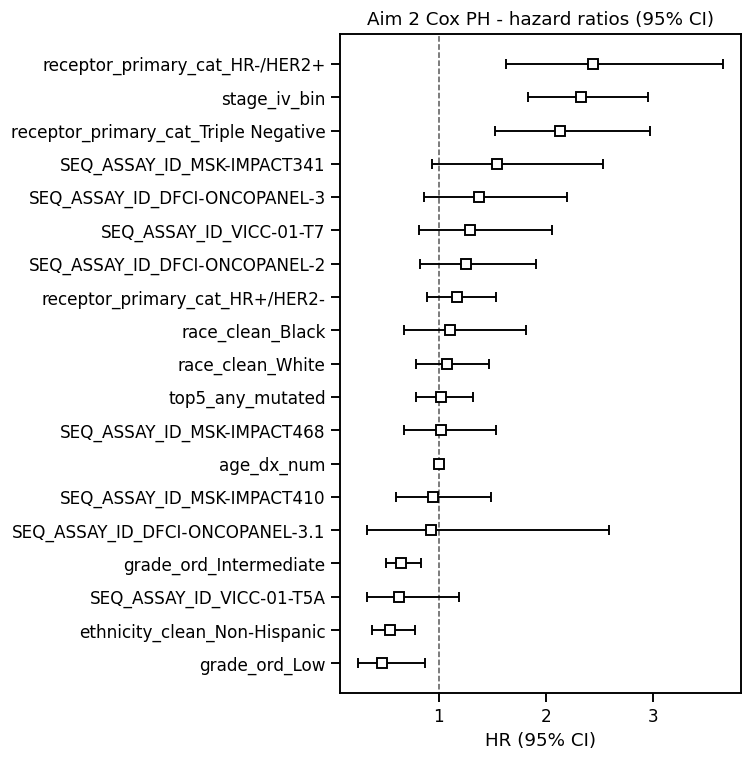

In [6]:
# Cox PH forest plot
fig, ax = plt.subplots(figsize=(7, max(3, 0.32*len(cox_summary)+1)))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title('Aim 2 Cox PH - hazard ratios (95% CI)')
plt.tight_layout()
plt.savefig(FIG / 'aim2_cox_forest.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.1 PH assumption check (Schoenfeld, Section 9.3)

                                term  test_statistic        p  -log2(p)
       SEQ_ASSAY_ID_DFCI-ONCOPANEL-2        0.270278 0.603145  0.729423
       SEQ_ASSAY_ID_DFCI-ONCOPANEL-3        0.008540 0.926369  0.110342
     SEQ_ASSAY_ID_DFCI-ONCOPANEL-3.1        0.754777 0.384968  1.377189
          SEQ_ASSAY_ID_MSK-IMPACT341        0.328029 0.566822  0.819033
          SEQ_ASSAY_ID_MSK-IMPACT410        0.217360 0.641059  0.641471
          SEQ_ASSAY_ID_MSK-IMPACT468        0.106109 0.744618  0.425427
            SEQ_ASSAY_ID_VICC-01-T5A        1.358090 0.243869  2.035823
             SEQ_ASSAY_ID_VICC-01-T7        0.488686 0.484514  1.045389
                          age_dx_num        0.304356 0.581165  0.782981
        ethnicity_clean_Non-Hispanic        6.008402 0.014238  6.134118
              grade_ord_Intermediate        0.247913 0.618549  0.693041
                       grade_ord_Low        0.003267 0.954417  0.067308
                    race_clean_Black        4.246592 0.039329  4


   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...



The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'stage_iv_bin' failed the non-proportional test: p-value is 0.0143.

   Advice: with so few unique values (only 2), you can include `strata=['stage_iv_bin', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...



...


   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...




---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



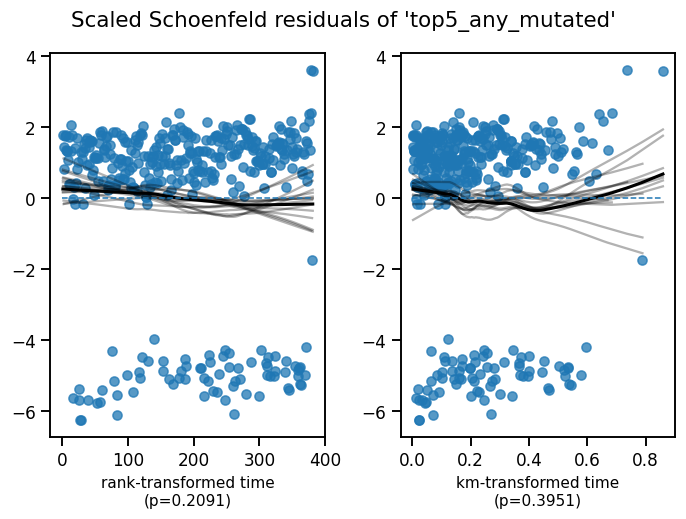

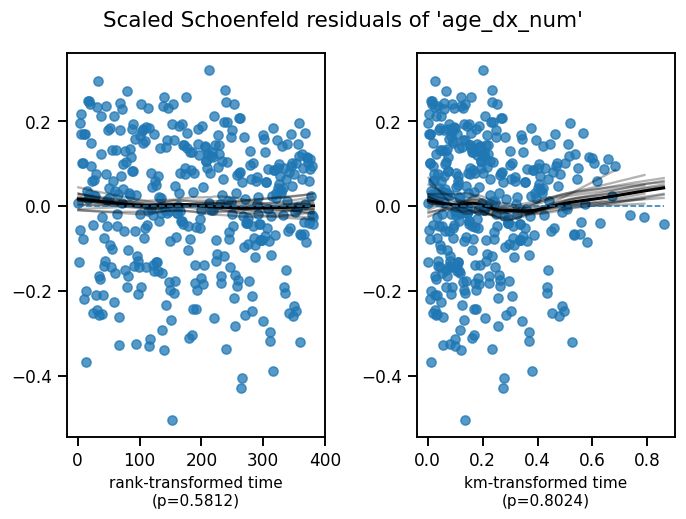

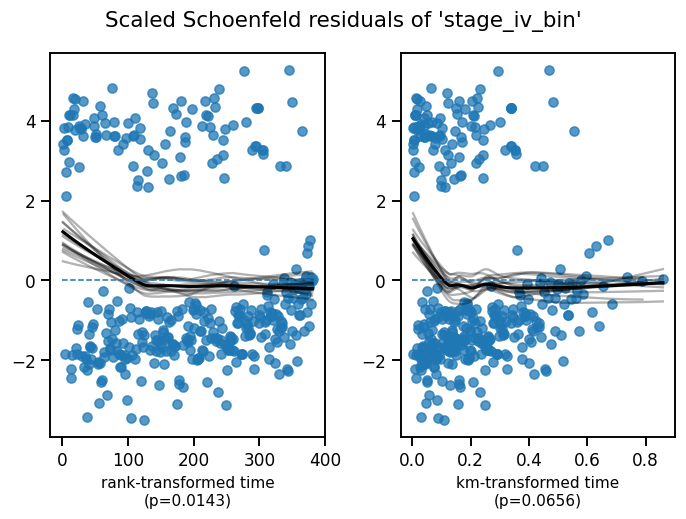

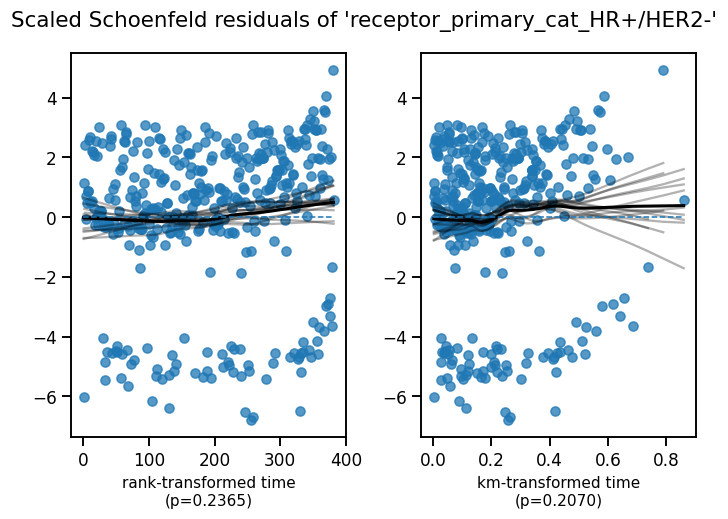

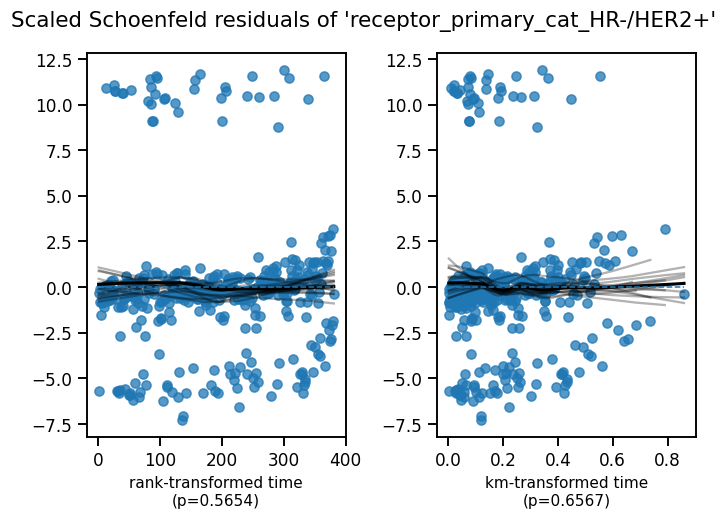

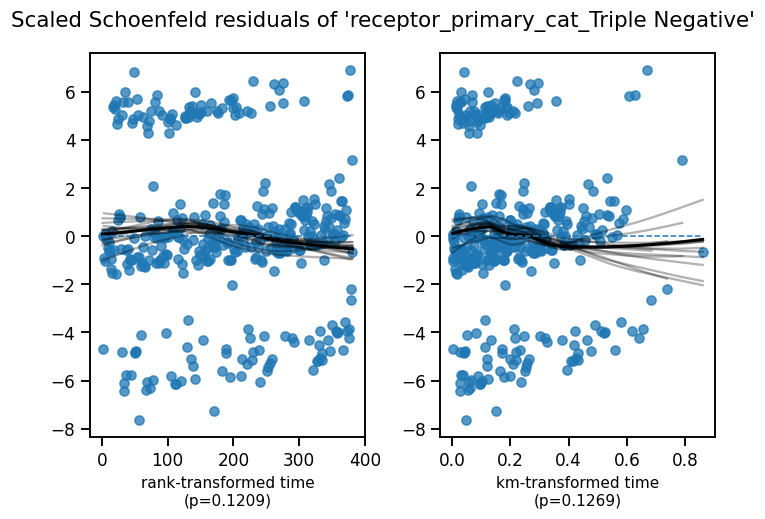

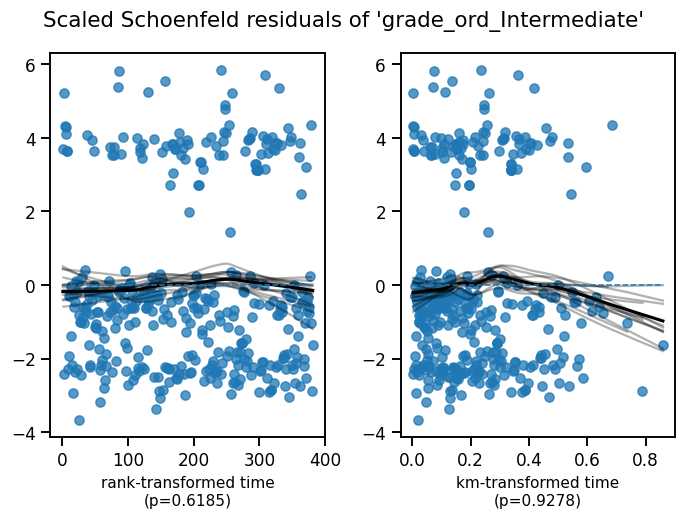

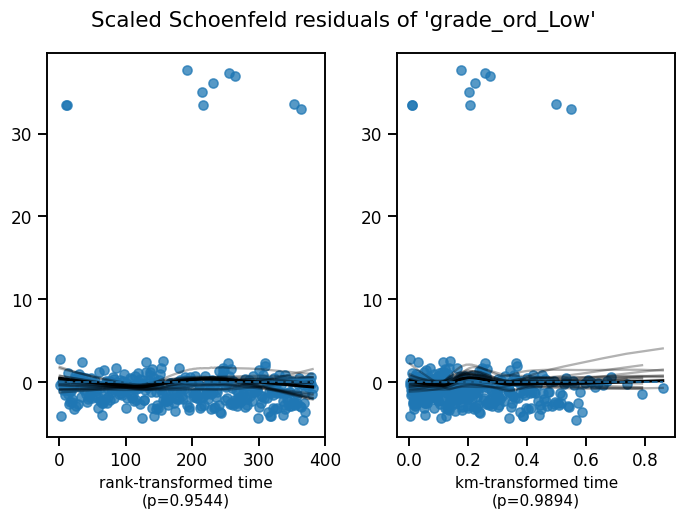

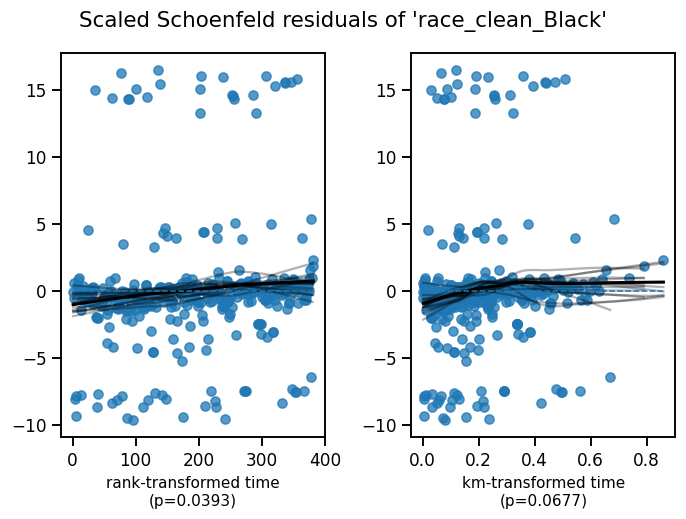

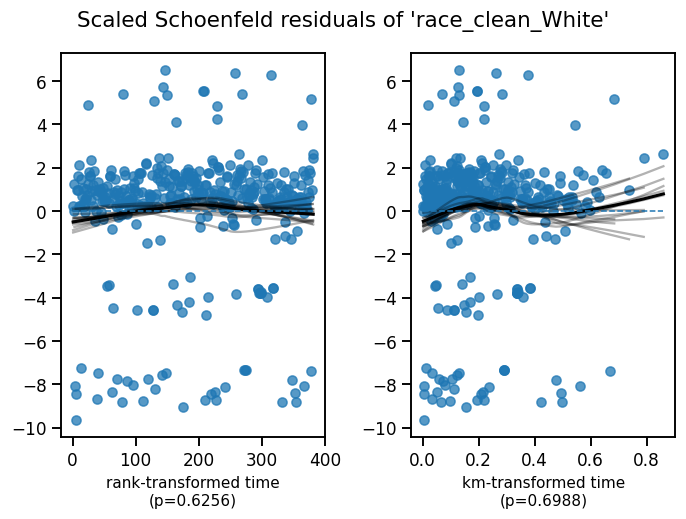

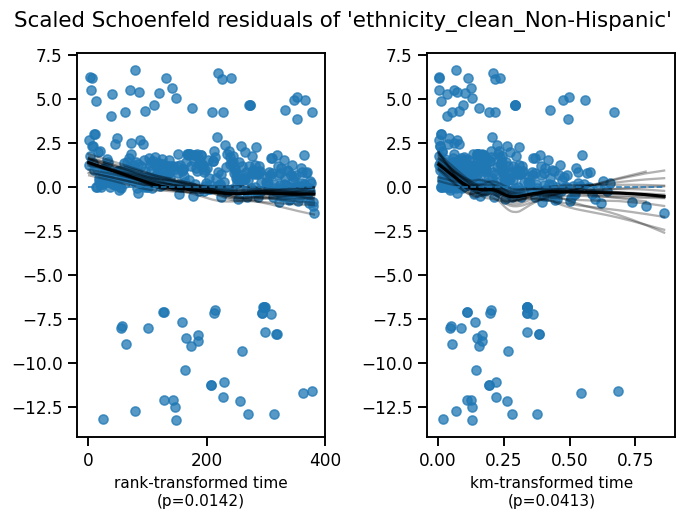

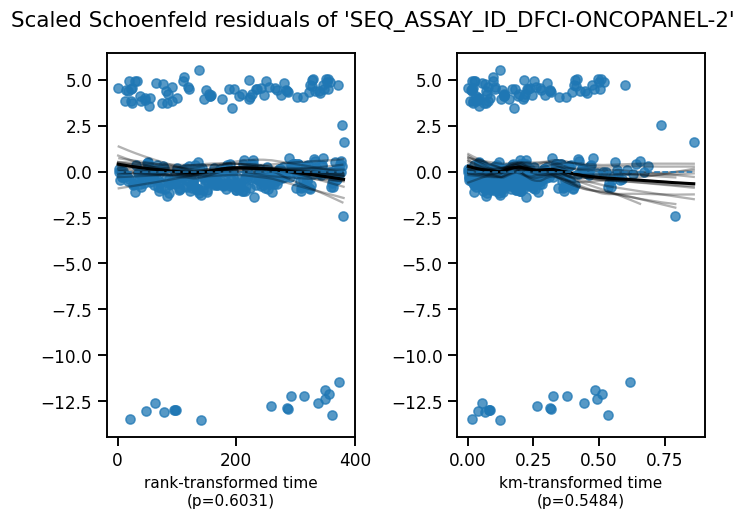

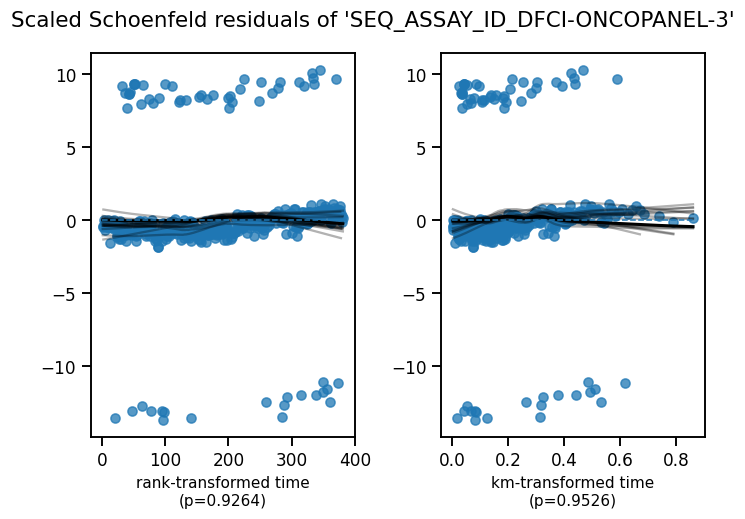

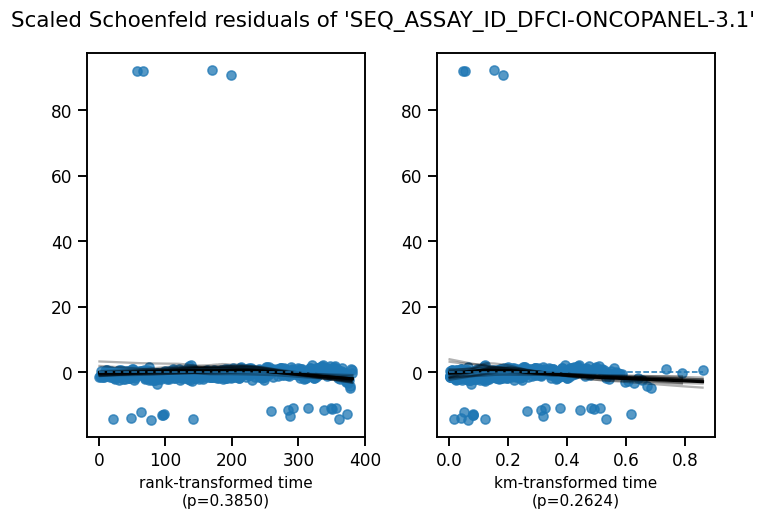

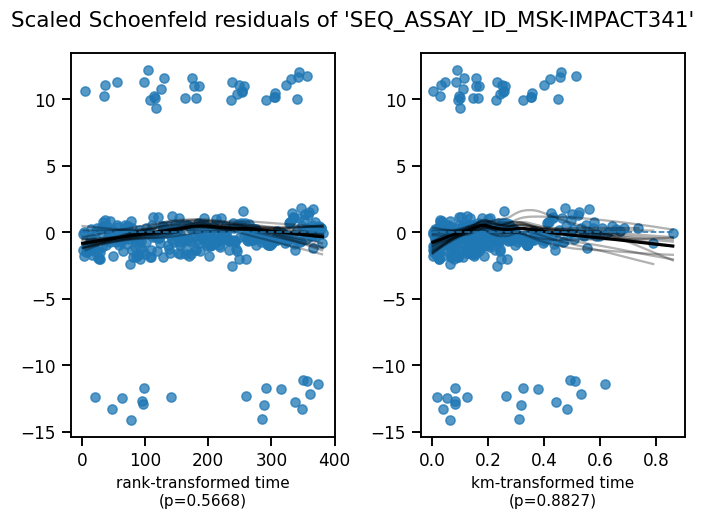

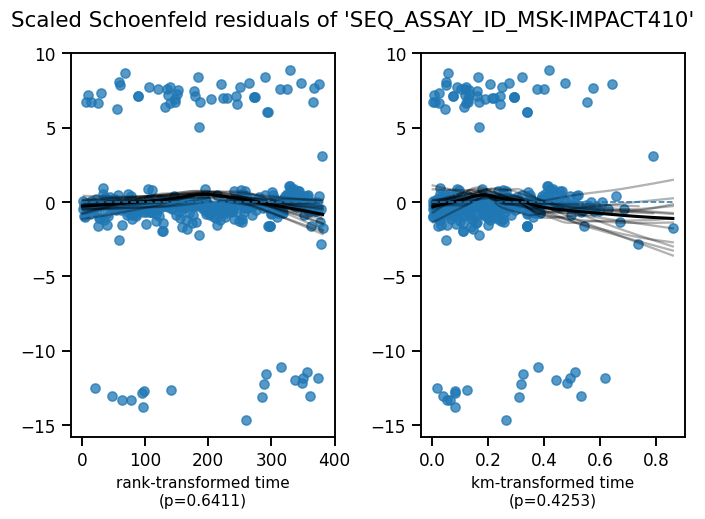

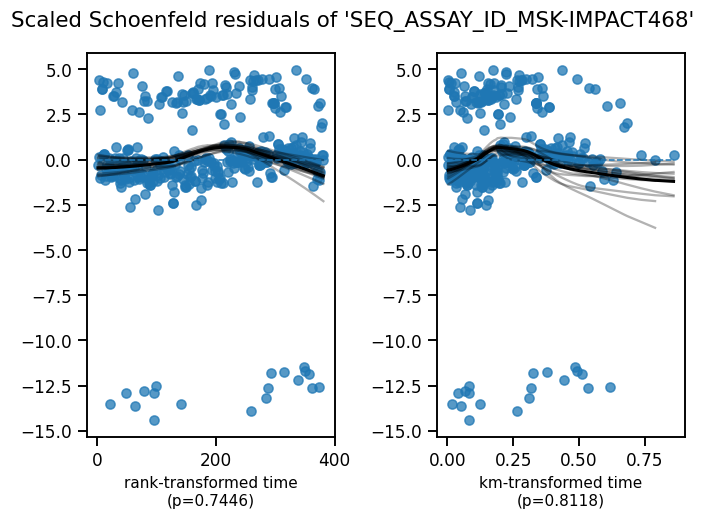

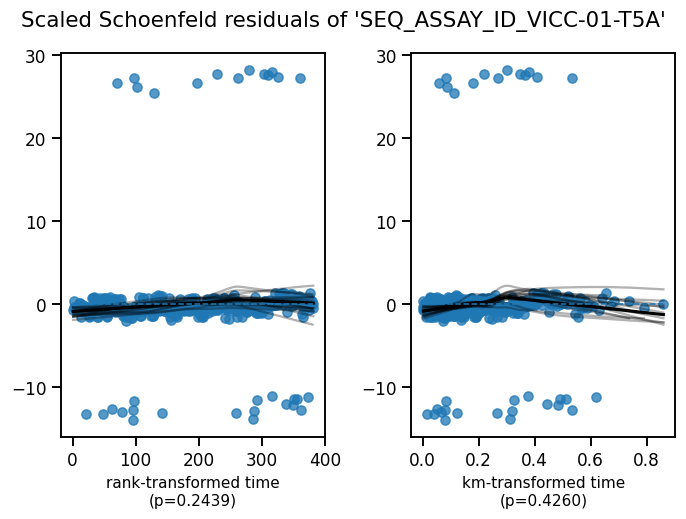

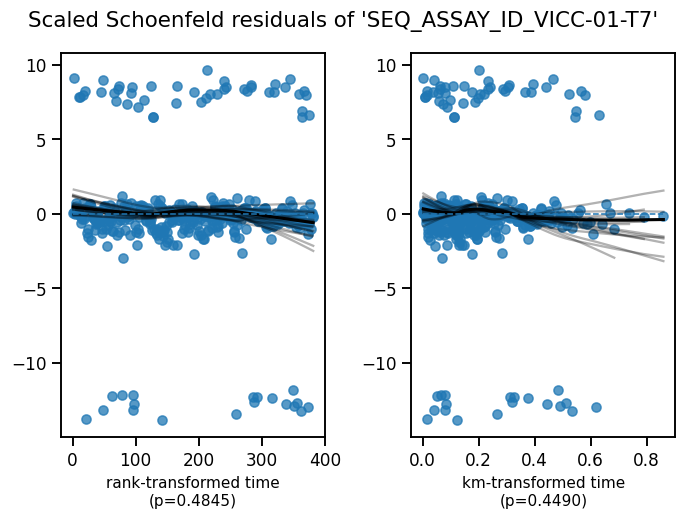

In [7]:
zph = proportional_hazard_test(cph, fit_df, time_transform='rank')
zph_df = zph.summary.reset_index().rename(columns={'index':'term'})
zph_df.to_csv(OUT / 'aim2_cox_zph.csv', index=False)
print(zph_df.to_string(index=False))

violators = zph_df.loc[zph_df['p'] < 0.05, 'term'].tolist()
print('\nPH violators (p<0.05):', violators)
if violators:
    cph.check_assumptions(fit_df, p_value_threshold=0.05, show_plots=True)

## 3. AFT distribution selection (Section 8.3)

Fit Weibull / log-normal / log-logistic. Pick best by AIC. Same logic as `aim2_tte_brain_met.py`.

In [8]:
fitters = {
    'weibull':     WeibullAFTFitter(penalizer=0.01),
    'lognormal':   LogNormalAFTFitter(penalizer=0.01),
    'loglogistic': LogLogisticAFTFitter(penalizer=0.01),
}
results = []
for name, f in fitters.items():
    try:
        f.fit(fit_df, duration_col='tt_brain_met_mos', event_col='brain_met_event',
              show_progress=False)
        results.append(dict(distribution=name, AIC=f.AIC_,
                            log_likelihood=f.log_likelihood_,
                            concordance=f.concordance_index_))
    except Exception as e:
        print(f'WARN: AFT {name} failed: {e}')
aft_cmp = pd.DataFrame(results).sort_values('AIC')
aft_cmp.to_csv(OUT / 'aim2_aft_dist_comparison.csv', index=False)
print(aft_cmp.to_string(index=False))

best_name = aft_cmp.iloc[0]['distribution']
best_fit  = fitters[best_name]
aft_summary = best_fit.summary.reset_index().rename(columns={'covariate':'term'})
aft_summary['distribution'] = best_name
aft_summary.to_csv(OUT / 'aim2_aft.csv', index=False)
print(f'\nBest by AIC: {best_name}')
best_fit.print_summary(decimals=3)

distribution         AIC  log_likelihood  concordance
 loglogistic 4688.787709    -2323.393854     0.690865
     weibull 4694.448591    -2326.224296     0.686184
   lognormal 4729.080722    -2343.540361     0.692017

Best by AIC: loglogistic


<lifelines.LogLogisticAFTFitter: fitted with 1222 total observations, 841 right-censored observations>
             duration col = 'tt_brain_met_mos'
                event col = 'brain_met_event'
                penalizer = 0.01
   number of observations = 1222
number of events observed = 381
           log-likelihood = -2323.394
         time fit was run = 2026-07-14 03:10:36 UTC

---
                                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                              
alpha_ SEQ_ASSAY_ID_DFCI-ONCOPANEL-2        -0.221     0.802     0.186          -0.586           0.144               0.556               1.155
       SEQ_ASSAY_ID_DFCI-ONCOPANEL-3        -0.237     0.789     0.204          -0.637           0.162               0.529               1.176
       SEQ_ASSAY_ID_DFCI-ONCOPANEL-3.1      -0.000     1.000     0.413          -0.810           0.810               0.445               2.247
       SEQ_ASSAY_ID_MSK-IMPACT341           -0.338     0.713     0.225          -0.779           0.102               0.459               1.107
       SEQ_ASSAY_ID_MSK-IMPACT410            0.000     1.000     0.200          -0.391           0.391               0.676               1.479
       SEQ_ASSAY_ID_MSK-IMPACT468           -0.033     0.967     0.182          -0.390           0.323               0.677               1.382
       SEQ_ASSAY_ID_VICC-01-T5A              0.411     1.509     0.263          -0.104           0.926               0.901               2.526
       SEQ_ASSAY_ID_VICC-01-T7              -0.242     0.785     0.205          -0.644           0.160               0.525               1.173
       age_dx_num                           -0.003     0.997     0.006          -0.015           0.009               0.985               1.009
       ethnicity_clean_Non-Hispanic          0.370     1.448     0.156           0.065           0.676               1.067               1.966
       grade_ord_Intermediate                0.352     1.423     0.102           0.152           0.553               1.164               1.738
       grade_ord_Low                         0.575     1.777     0.243           0.098           1.051               1.103               2.862
       race_clean_Black                      0.043     1.044     0.202          -0.353           0.439               0.702               1.551
       race_clean_White                     -0.061     0.941     0.131          -0.319           0.196               0.727               1.217
       receptor_primary_cat_HR+/HER2-       -0.115     0.891     0.116          -0.343           0.113               0.710               1.120
       receptor_primary_cat_HR-/HER2+       -0.770     0.463     0.177          -1.117          -0.422               0.327               0.656
       receptor_primary_cat_Triple Negative -0.689     0.502     0.144          -0.971          -0.408               0.379               0.665
       stage_iv_bin                         -0.744     0.475     0.102          -0.944          -0.544               0.389               0.580
       top5_any_mutated                     -0.053     0.949     0.106          -0.261           0.155               0.770               1.168
       Intercept                             5.007   149.448     0.333           4.354           5.660              77.802             287.070
beta_  Intercept                             0.431     1.539     0.042           0.349           0.513               1.417               1.671

                                             cmp to      z       p  -log2(p)
param  covariate                                                            
alpha_ SEQ_ASSAY_ID_DFCI-ONCOPANEL-2          0.000 -1.186   0.236     2.084
       SEQ_ASSAY_ID_DFCI-ONCOPANEL-3          0.000 -1.163   0.245     2.031
       SEQ_AS

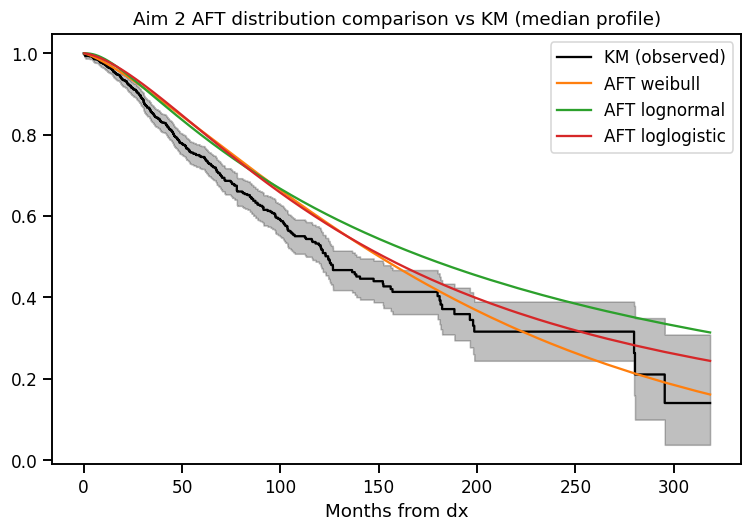

In [9]:
# Distribution comparison plot - KM vs each AFT predicted at median-covariate profile
fig, ax = plt.subplots(figsize=(7, 5))
kmf = KaplanMeierFitter()
kmf.fit(fit_df['tt_brain_met_mos'], event_observed=fit_df['brain_met_event'], label='KM (observed)')
kmf.plot_survival_function(ax=ax, color='black')
median_profile = fit_df.median(numeric_only=True).to_frame().T
for name, f in fitters.items():
    try:
        s = f.predict_survival_function(median_profile).mean(axis=1)
        s.plot(ax=ax, label=f'AFT {name}')
    except Exception:
        pass
ax.set_title('Aim 2 AFT distribution comparison vs KM (median profile)')
ax.set_xlabel('Months from dx'); ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'aim2_aft_distribution_compare.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Secondary specifications

Per Section 8.2 / Section 11:
- (a) Replace exposure with `top5_n_mutated` (0-5 continuous)
- (b) Per-gene `G_top10_<GENE>` univariate Cox + BH correction (hypothesis-generating, from `genie_scripts_xgb_aft/run_per_gene_cox_pfs.py`)
- (c) Sensitivity: replace top-5 with `top10_any_mutated` (Section 11 #4)

In [10]:
# (a) - top5_n_mutated
base_n = base.copy()
cov_n = L.prep_covariates(base_n, include_stage_iv=True)
# Replace top5_any_mutated column with top5_n_mutated
cov_n = cov_n.drop(columns=['top5_any_mutated'])
cov_n['top5_n_mutated'] = pd.to_numeric(base_n['top5_n_mutated'], errors='coerce')
cph_n_df = pd.concat([base_n[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                      cov_n.reset_index(drop=True)], axis=1).dropna()
cph_n_df = cph_n_df[cph_n_df['tt_brain_met_mos']>0]
cov_keep = L.drop_low_variance(cph_n_df.drop(columns=['tt_brain_met_mos','brain_met_event']))
fit_n_df = pd.concat([cph_n_df[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                      cov_keep.reset_index(drop=True)], axis=1)
cph_n = CoxPHFitter(penalizer=0.01).fit(fit_n_df, duration_col='tt_brain_met_mos', event_col='brain_met_event',
                                        show_progress=False)
cph_n.summary.reset_index().to_csv(OUT / 'aim2_cox_top5_n_mutated.csv', index=False)
print('top5_n_mutated coef:')
print(cph_n.summary.loc[['top5_n_mutated']])

top5_n_mutated coef:
                    coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                       
top5_n_mutated  0.076782   1.079806  0.073513         -0.0673        0.220864   

                exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                                    
top5_n_mutated             0.934914             1.247153     0.0  1.044468   

                       p  -log2(p)  
covariate                           
top5_n_mutated  0.296269  1.755022  


In [11]:
# (b) - per-gene G_top10_<GENE> univariate Cox + BH (from run_per_gene_cox_pfs.py shape)
rows = []
for g in TOP10:
    col = f'G_top10_{g}'
    if col not in base.columns: continue
    sub = base[[col, 'tt_brain_met_mos', 'brain_met_event']].dropna()
    sub = sub[sub['tt_brain_met_mos'] > 0]
    if sub[col].sum() < 5: continue
    fit = CoxPHFitter().fit(sub, duration_col='tt_brain_met_mos', event_col='brain_met_event', show_progress=False)
    s = fit.summary.iloc[0]
    rows.append(dict(gene=g, HR=s['exp(coef)'], lo=s['exp(coef) lower 95%'], hi=s['exp(coef) upper 95%'],
                     p=s['p'], n_mut=int(sub[col].sum()), n=len(sub),
                     n_events=int(sub['brain_met_event'].sum())))
per_gene = pd.DataFrame(rows)
if len(per_gene):
    per_gene['p_bh'] = multipletests(per_gene['p'].fillna(1.0), method='fdr_bh')[1]
per_gene.to_csv(OUT / 'aim2_per_gene_univariate_cox.csv', index=False)
per_gene

,gene,HR,lo,hi,p,n_mut,n,n_events,p_bh
0,TP53,1.889565,1.542191,2.315185,8.272562e-10,563,1222,381,8.272562e-09
1,PIK3CA,0.852167,0.681789,1.065123,1.598393e-01,350,1222,381,3.995983e-01
2,GATA3,0.670787,0.490997,0.916410,1.213127e-02,173,1222,381,6.065634e-02
3,CDH1,0.823679,0.576104,1.177648,2.875707e-01,120,1222,381,5.751413e-01
4,PTEN,1.036606,0.689984,1.557357,8.625607e-01,72,1222,381,8.625607e-01
5,NF1,1.444716,0.955214,2.185065,8.135038e-02,62,1222,381,2.711679e-01
6,ARID1A,0.894353,0.575827,1.389073,6.191647e-01,81,1222,381,8.400071e-01
7,KMT2D,0.846579,0.554640,1.292183,4.401600e-01,77,1222,381,7.335999e-01
8,BRCA2,1.097598,0.713223,1.689124,6.720057e-01,64,1222,381,8.400071e-01
9,KMT2C,1.054511,0.678777,1.638229,8.133250e-01,59,1222,381,8.625607e-01


In [12]:
# (c) - sensitivity: top10_any_mutated
cov_10 = L.prep_covariates(base, include_stage_iv=True)
cov_10 = cov_10.drop(columns=['top5_any_mutated'])
cov_10['top10_any_mutated'] = pd.to_numeric(base['top10_any_mutated'], errors='coerce')
cph_10_df = pd.concat([base[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                       cov_10.reset_index(drop=True)], axis=1).dropna()
cph_10_df = cph_10_df[cph_10_df['tt_brain_met_mos']>0]
kept = L.drop_low_variance(cph_10_df.drop(columns=['tt_brain_met_mos','brain_met_event']))
fit_10 = pd.concat([cph_10_df[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                    kept.reset_index(drop=True)], axis=1)
cph_10 = CoxPHFitter(penalizer=0.01).fit(fit_10, duration_col='tt_brain_met_mos', event_col='brain_met_event',
                                         show_progress=False)
cph_10.summary.reset_index().to_csv(OUT / 'aim2_cox_sensitivity_top10.csv', index=False)
print('top10_any_mutated coef:')
print(cph_10.summary.loc[['top10_any_mutated']])

top10_any_mutated coef:
                       coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                          
top10_any_mutated -0.030453   0.970006  0.143504       -0.311715   

                   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                     
top10_any_mutated        0.250809              0.73219             1.285065   

                   cmp to         z         p  -log2(p)  
covariate                                                
top10_any_mutated     0.0 -0.212208  0.831944  0.265441  


## 5. Cross-validated C-index (5-fold, stratified by event)

Section 9.3 calls for 5-fold (or repeated 10-fold) for the C-index. We mirror that here.

In [13]:
from sklearn.model_selection import StratifiedKFold
from lifelines.utils import concordance_index

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(fit_df, fit_df['brain_met_event']), 1):
    tr, te = fit_df.iloc[tr_idx], fit_df.iloc[te_idx]
    fit = CoxPHFitter(penalizer=0.01).fit(tr, duration_col='tt_brain_met_mos',
                                          event_col='brain_met_event', show_progress=False)
    risk = fit.predict_partial_hazard(te).values
    ci = concordance_index(te['tt_brain_met_mos'], -risk, te['brain_met_event'])
    rows.append({'fold':fold,'c_index':ci,'n_test':len(te),'n_events_test':int(te['brain_met_event'].sum())})
    print(f'Fold {fold}: C-index={ci:.3f}  n_test={len(te)}')
ci_df = pd.DataFrame(rows)
ci_df.to_csv(OUT / 'aim2_cox_5fold_cindex.csv', index=False)
print(f'\nMean C-index = {ci_df["c_index"].mean():.3f}  (SD {ci_df["c_index"].std():.3f})')

Fold 1: C-index=0.616  n_test=245
Fold 2: C-index=0.661  n_test=245


Fold 3: C-index=0.701  n_test=244
Fold 4: C-index=0.603  n_test=244


Fold 5: C-index=0.731  n_test=244

Mean C-index = 0.662  (SD 0.055)


## 6. Optional - multi-cohort loop (genie / tcga / msk18)

Set `RUN_MULTI_COHORT = True` to re-run Aim 2 across the other harmonised cohorts.

In [14]:
RUN_MULTI_COHORT = False
if RUN_MULTI_COHORT:
    for c in ['tcga', 'msk18']:
        try:
            dc = L.load_cohort(c)
            bc = dc[dc['brain_met_at_dx']==0].copy()
            events_c = int(bc['brain_met_event'].sum())
            print(f'\n=== {c.upper()}  n={len(bc)}  events={events_c} ===')
            if events_c < MIN_EVENTS:
                print(f'  SKIP: events {events_c} < {MIN_EVENTS}')
                continue
            cov_c = L.prep_covariates(bc, include_stage_iv=True)
            mdf_c = pd.concat([bc[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                               cov_c.reset_index(drop=True)], axis=1).dropna()
            mdf_c = mdf_c[mdf_c['tt_brain_met_mos']>0]
            mdf_c_cov = L.drop_low_variance(mdf_c.drop(columns=['tt_brain_met_mos','brain_met_event']))
            fit_c = pd.concat([mdf_c[['tt_brain_met_mos','brain_met_event']].reset_index(drop=True),
                               mdf_c_cov.reset_index(drop=True)], axis=1)
            cph_c = CoxPHFitter(penalizer=0.01).fit(fit_c, duration_col='tt_brain_met_mos',
                                                   event_col='brain_met_event', show_progress=False)
            cph_c.summary.reset_index().to_csv(OUT / f'aim2_cox_{c}.csv', index=False)
            print(f'  C-index({c}) = {cph_c.concordance_index_:.3f}')
        except FileNotFoundError as e:
            print(f'  SKIP {c}: {e}')

## 7. Deliverables

| File | README mapping |
|---|---|
| `aim2_logrank.csv`, `aim2_km.png` | Section 12 row 4 |
| `aim2_cox.csv`, `aim2_cox_forest.png`, `aim2_cox_zph.csv` | Section 12 row 5 + Section 9.3 |
| `aim2_aft_dist_comparison.csv`, `aim2_aft.csv`, `aim2_aft_distribution_compare.png` | Section 12 rows 6, 10 |
| `aim2_cox_top5_n_mutated.csv`, `aim2_cox_sensitivity_top10.csv`, `aim2_per_gene_univariate_cox.csv` | Section 11 #4, #5, #8 |
| `aim2_cox_5fold_cindex.csv` | Section 12 row 12 |